# 05 - Price Explainability

**Mục tiêu:** giải thích final pipeline đã lưu, không train hoặc tuning lại. **Input:** model metadata, selected features, test predictions và Gold mart. **Output:** `ml/outputs/price_explainability/`.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from scipy import sparse
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.motherduck import close_connection, connect_motherduck
from utils.sql import query_dataframe

RANDOM_STATE = 42
SOURCE_TABLE = "gold.gold_price_model_features"
MODEL_OUTPUT = PROJECT_ROOT / "ml" / "outputs" / "price_modeling"
EXPLAIN_OUTPUT = PROJECT_ROOT / "ml" / "outputs" / "price_explainability"
for folder in ("csv", "charts", "summary"):
    (EXPLAIN_OUTPUT / folder).mkdir(parents=True, exist_ok=True)

artifact = joblib.load(MODEL_OUTPUT / "models" / "final_price_model.joblib")
if not isinstance(artifact, dict) or "pipeline" not in artifact:
    raise ValueError("Expected the final model artifact dictionary created by notebook 03.")
pipeline = artifact["pipeline"]
selected_features = artifact.get("model_features") or artifact.get("selected_features")
if not selected_features:
    raise ValueError("Final model artifact does not contain its feature list.")
predictions = pd.read_csv(MODEL_OUTPUT / "csv" / "15_final_test_predictions.csv")
required_prediction_columns = {
    "listing_id", "actual_log_price", "predicted_log_price", "residual_log",
    "actual_price", "predicted_price", "absolute_error_price",
}
missing_prediction_columns = required_prediction_columns.difference(predictions.columns)
if missing_prediction_columns:
    raise ValueError(f"Prediction artifact missing columns: {sorted(missing_prediction_columns)}")
if predictions["listing_id"].duplicated().any():
    raise ValueError("Prediction artifact contains duplicate listing_id values.")
predictions["residual_price"] = predictions["actual_price"] - predictions["predicted_price"]

preprocessor = pipeline.named_steps["preprocessor"]
estimator = pipeline.named_steps["model"]
transformed_names = preprocessor.get_feature_names_out().tolist()


def group_property_type(value):
    if pd.isna(value):
        return "Unknown"
    text = str(value).lower().strip()
    if any(item in text for item in ["serviced apartment", "aparthotel"]): return "Serviced Apartment / Aparthotel"
    if "hostel" in text: return "Hostel"
    if any(item in text for item in ["guesthouse", "guest house", "bed and breakfast"]): return "Guesthouse / B&B"
    if any(item in text for item in ["hotel", "resort", "ryokan", "kezhan"]): return "Hotel / Resort"
    if "villa" in text: return "Villa"
    if "loft" in text: return "Loft"
    if any(item in text for item in ["rental unit", "condo", "apartment"]): return "Apartment / Condo"
    if any(item in text for item in ["treehouse", "tiny home", "earthen home", "earth home", "dome", "tower", "lighthouse", "castle", "shipping container", "container", "hut", "tent"]): return "Unique Stay"
    if any(item in text for item in ["cabin", "nature lodge", "farm stay", "barn", "houseboat", "boat", "island", "camper/rv"]): return "Special Stay"
    if any(item in text for item in ["townhouse", "guest suite", "vacation home", "casa particular", "bungalow", "cottage", "chalet", "house", "home"]): return "House / Home"
    return "Other"


def prepare_features(dataframe):
    data = dataframe.copy()
    if "property_type" in data.columns:
        data["property_base_group"] = data["property_type"].apply(group_property_type)
        data = data.drop(columns="property_type")
    if {"has_reviews", "reviews_per_month"}.issubset(data.columns):
        data.loc[data["has_reviews"] == 0, "reviews_per_month"] = 0
    return data

## 1. Nạp test data đúng theo listing_id đã lưu

    Test IDs được artifact từ notebook 03 lưu lại; không tái chia dữ liệu và không fit lại model.

In [2]:
connection = connect_motherduck(read_only=True)
try:
    gold = query_dataframe(connection, f"select * from {SOURCE_TABLE}")
finally:
    close_connection(connection)
if gold.empty or gold["listing_id"].duplicated().any():
    raise ValueError("Gold feature mart must be non-empty with unique listing_id values.")

test = predictions[["listing_id"]].merge(gold, on="listing_id", how="left", validate="one_to_one")
if len(test) != len(predictions) or test["log_price"].isna().any():
    raise ValueError("Could not reconstruct test data from the stored listing IDs.")
test = prepare_features(test)
missing_features = sorted(set(selected_features).difference(test.columns))
if missing_features:
    raise ValueError(f"Gold test data is missing model features: {missing_features}")
X_test = test[selected_features].copy()
y_test = predictions["actual_log_price"].copy()

## 2. Global importance và permutation importance

In [3]:
def raw_feature_name(transformed_name):
    display_name = str(transformed_name).split("__", 1)[-1]
    return next((feature for feature in sorted(selected_features, key=len, reverse=True) if display_name == feature or display_name.startswith(f"{feature}_")), display_name)

if hasattr(estimator, "feature_importances_"):
    model_importance = pd.DataFrame({"transformed_feature": transformed_names, "importance": estimator.feature_importances_})
    model_importance["feature"] = model_importance["transformed_feature"].map(raw_feature_name)
    global_importance = model_importance.groupby("feature", as_index=False)["importance"].sum().sort_values("importance", ascending=False)
else:
    global_importance = pd.DataFrame(columns=["feature", "importance"])
global_importance.to_csv(EXPLAIN_OUTPUT / "csv" / "01_global_feature_importance.csv", index=False)

sample = X_test.sample(min(1000, len(X_test)), random_state=RANDOM_STATE)
permutation = permutation_importance(pipeline, sample, y_test.loc[sample.index], scoring="neg_root_mean_squared_error", n_repeats=10, random_state=RANDOM_STATE, n_jobs=1)
permutation_frame = pd.DataFrame({"feature": selected_features, "importance_mean": permutation.importances_mean, "importance_std": permutation.importances_std}).sort_values("importance_mean", ascending=False)
permutation_frame.to_csv(EXPLAIN_OUTPUT / "csv" / "02_permutation_importance.csv", index=False)

## 3. SHAP đúng scale log-price

    Dữ liệu được transform bằng fitted preprocessor. Chỉ tạo SHAP nếu final estimator là tree model tương thích; reconstruction được kiểm tra thay vì nới tolerance.

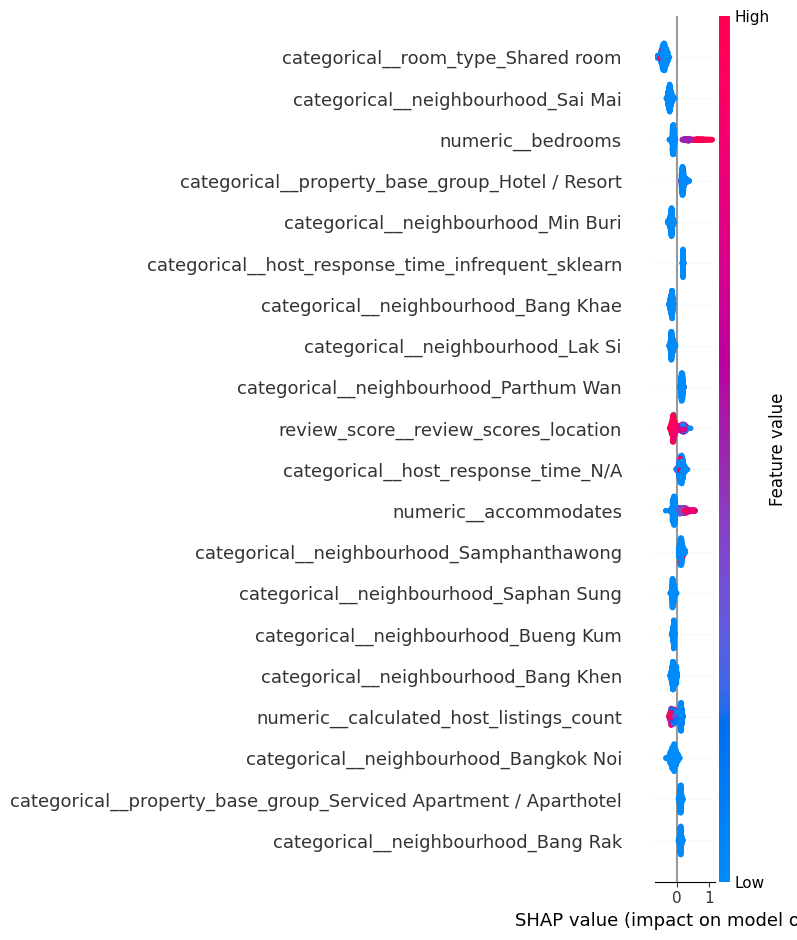

{'available': True, 'reconstruction_max_abs_error': 1.811981201171875e-05}

In [4]:
shap_status = {"available": False, "reason": ""}
transformed_sample = preprocessor.transform(sample)
if sparse.issparse(transformed_sample):
    transformed_sample = transformed_sample.toarray()
try:
    if estimator.__class__.__name__ not in {"XGBRegressor", "CatBoostRegressor", "RandomForestRegressor", "HistGradientBoostingRegressor"}:
        raise TypeError(f"{estimator.__class__.__name__} does not have a supported tree SHAP explainer.")
    explainer = shap.TreeExplainer(estimator)
    shap_values = np.asarray(explainer.shap_values(transformed_sample, check_additivity=False))
    expected_value = np.asarray(explainer.expected_value).reshape(-1)[0]
    model_prediction = estimator.predict(transformed_sample)
    reconstruction_error = np.max(np.abs(expected_value + shap_values.sum(axis=1) - model_prediction))
    if reconstruction_error > 1e-4:
        raise RuntimeError(f"SHAP reconstruction error {reconstruction_error:.6g} exceeds 1e-4.")
    shap_transformed = pd.DataFrame({"transformed_feature": transformed_names, "mean_abs_shap": np.abs(shap_values).mean(axis=0)})
    shap_transformed["feature"] = shap_transformed["transformed_feature"].map(raw_feature_name)
    shap_aggregated = shap_transformed.groupby("feature", as_index=False)["mean_abs_shap"].sum().sort_values("mean_abs_shap", ascending=False)
    shap_transformed.to_csv(EXPLAIN_OUTPUT / "csv" / "03_shap_importance_transformed.csv", index=False)
    shap_aggregated.to_csv(EXPLAIN_OUTPUT / "csv" / "04_shap_importance_aggregated.csv", index=False)
    plt.figure(); shap.summary_plot(shap_values, transformed_sample, feature_names=transformed_names, show=False); plt.tight_layout(); plt.savefig(EXPLAIN_OUTPUT / "charts" / "02_shap_beeswarm.png", dpi=150); plt.show()
    shap_status = {"available": True, "reconstruction_max_abs_error": float(reconstruction_error)}
except Exception as error:
    shap_status = {"available": False, "reason": str(error), "fallback": "Permutation importance remains available; no invalid SHAP output was written."}
(EXPLAIN_OUTPUT / "summary" / "01_shap_status.json").write_text(json.dumps(shap_status, indent=2), encoding="utf-8")
shap_status

## 4. Partial dependence và local explanations

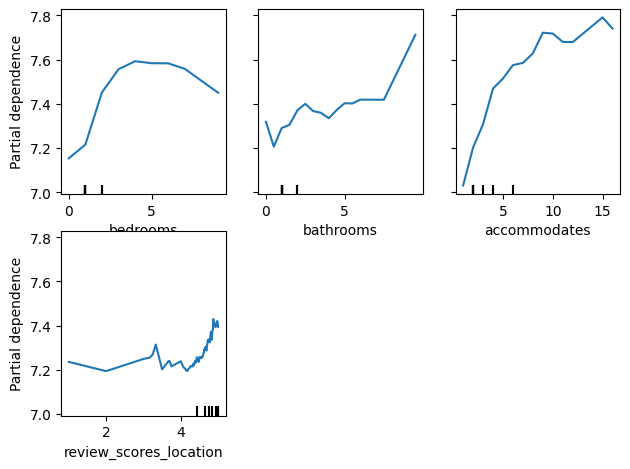

Feature importance and SHAP describe the learned model relationship on log-price, not causal effects.


In [5]:
numeric_for_pdp = [feature for feature in selected_features if pd.api.types.is_numeric_dtype(X_test[feature])][:6]
if numeric_for_pdp:
    pdp_sample = sample.copy()
    for feature in numeric_for_pdp:
        pdp_sample[feature] = pd.to_numeric(pdp_sample[feature], errors="coerce").astype("float64")
    PartialDependenceDisplay.from_estimator(pipeline, pdp_sample, numeric_for_pdp[:4])
    plt.tight_layout()
    plt.savefig(EXPLAIN_OUTPUT / "charts" / "01_partial_dependence.png", dpi=150)
    plt.show()

cases = {
    "accurate_prediction": predictions["absolute_error_price"].idxmin(),
    "overprediction": predictions["residual_price"].idxmin(),
    "underprediction": predictions["residual_price"].idxmax(),
    "low_price": predictions["actual_price"].idxmin(),
    "high_price": predictions["actual_price"].idxmax(),
}
local_rows = []
for case, index in cases.items():
    row = predictions.loc[index]
    local_rows.append({"case": case, "listing_id": row["listing_id"], "actual_price": row["actual_price"], "predicted_price": row["predicted_price"], "residual_price": row["residual_price"]})
pd.DataFrame(local_rows).to_csv(EXPLAIN_OUTPUT / "csv" / "05_local_explanations.csv", index=False)
print("Feature importance and SHAP describe the learned model relationship on log-price, not causal effects.")

## Kết luận explainability

- **Yếu tố chi phối nhất là vị trí.** Tree importance xếp `neighbourhood` đầu tiên (0,429); SHAP gộp cũng cho giá trị mean |SHAP| cao nhất (3,115). Kết quả này cho thấy khu vực là thông tin mô hình dùng rất mạnh khi dự báo `log_price`.
- **Quy mô và loại hình listing** là nhóm quan trọng kế tiếp: `bedrooms`, `accommodates`, `room_type` và `property_base_group` đều nằm trong nhóm dẫn đầu. Permutation importance cũng xác nhận `accommodates` (0,114) và `bedrooms` (0,100) là các feature có ảnh hưởng đáng kể đến RMSE khi bị xáo trộn.
- **Thuộc tính host có ý nghĩa bổ sung.** `host_total_listings_count`, `host_listings_count`, `calculated_host_listings_count`, `host_acceptance_rate` và `host_response_rate` có permutation importance dương; tuy nhiên mức độ thấp hơn vị trí và quy mô listing.
- **SHAP đã qua kiểm tra reconstruction.** Sai lệch tối đa là `1,81e-05`, nhỏ hơn ngưỡng `1e-04`; vì vậy các giải thích SHAP trong notebook này nhất quán với dự báo trên scale `log_price`.
- **Các case local cho thấy sai số lớn tập trung ở listing giá cao/outlier.** Case dự báo chính xác lệch khoảng 0,02 THB; trong khi case overprediction lệch khoảng 12.634 THB và case underprediction lệch khoảng 172.628 THB. Listing giá cao 184.368 THB là case underprediction rõ rệt, cho thấy model chưa bao quát tốt phần đuôi giá cao.
- **Diễn giải hướng tác động:** importance và SHAP cho biết feature nào mô hình dùng nhiều, nhưng không khẳng định quan hệ nhân quả. Hướng tăng/giảm giá cần đọc theo PDP, SHAP beeswarm và từng category cụ thể; đặc biệt với `neighbourhood`, `room_type` và `property_base_group`.
